In [2]:
import uproot
from tqdm import tqdm
import awkward as ak
import numpy as np
from collections import Counter
import glob
import os

input_dir = "/local/joosep/mlpf/cld/v1.2.5_key4hep_2025-05-29/gen/p8_ee_Z_tautau_ecm91/root/"
file_pattern = "*.root"
files = sorted(glob.glob(os.path.join(input_dir, file_pattern)))[:1000]

raw_daughter_pdgs = []

branches = [
    "MCParticles.PDG",
    "MCParticles.generatorStatus",
    "MCParticles.daughters_begin",
    "MCParticles.daughters_end",
    "_MCParticles_daughters.index",
]

for path in files:
    with uproot.open(path) as f:
        arrays = f["events"].arrays(branches)
        for event in arrays:
            d_idx = event["_MCParticles_daughters.index"]
            d_begin = event["MCParticles.daughters_begin"]
            d_end = event["MCParticles.daughters_end"]
            tau_mask = (np.abs(event["MCParticles.PDG"]) == 15) & (
                event["MCParticles.generatorStatus"] == 2
            )
            tau_indices = np.where(tau_mask)[0]
            for tau_idx in tau_indices:
                daughter_indices = d_idx[d_begin[tau_idx] : d_end[tau_idx]]
                raw_pdgs = [int(event["MCParticles.PDG"][d]) for d in daughter_indices]
                raw_daughter_pdgs.append(raw_pdgs)

flat_pdgs = [pdg for daughters in raw_daughter_pdgs for pdg in daughters]
print(Counter(flat_pdgs).most_common(30))

[(111, 109303), (16, 100004), (-16, 100004), (211, 93146), (-211, 93140), (11, 17790), (-12, 17782), (-11, 17652), (12, 17652), (-13, 17312), (14, 17312), (13, 17267), (-14, 17267), (321, 2305), (-321, 2227), (-311, 1687), (311, 1687), (221, 429), (22, 343), (130, 327), (310, 303), (223, 110), (323, 31), (-323, 30)]


In [16]:
import numpy as np
from collections import Counter

pdg_to_latex = {
    11: r"$e^\pm$",
    12: r"$\nu_e / \bar{\nu}_e$",
    13: r"$\mu^\pm$",
    14: r"$\nu_\mu / \bar{\nu}_\mu$",
    16: r"$\nu_\tau / \bar{\nu}_\tau$",
    22: r"$\gamma$",
    111: r"$\pi^0$",
    211: r"$\pi^\pm$",
    221: r"$\eta$",
    223: r"$\omega$",
    310: r"$K_S^0$",
    130: r"$K_L^0$",
    311: r"$K^0 / \bar{K}^0$",
    321: r"$K^\pm$",
    323: r"$K^{*\pm}$",
}

abs_flat_pdgs = np.abs(flat_pdgs)
count = Counter(abs_flat_pdgs).most_common(30)

# Map the most common PDGs to LaTeX
latex_labels = [pdg_to_latex.get(pdg, str(pdg)) for pdg, _ in count]
counts = [c for _, c in count]

cz = {}
for label, c in zip(latex_labels, counts):
    cz[label] = c

In [20]:
sum_ = sum(cz.values())

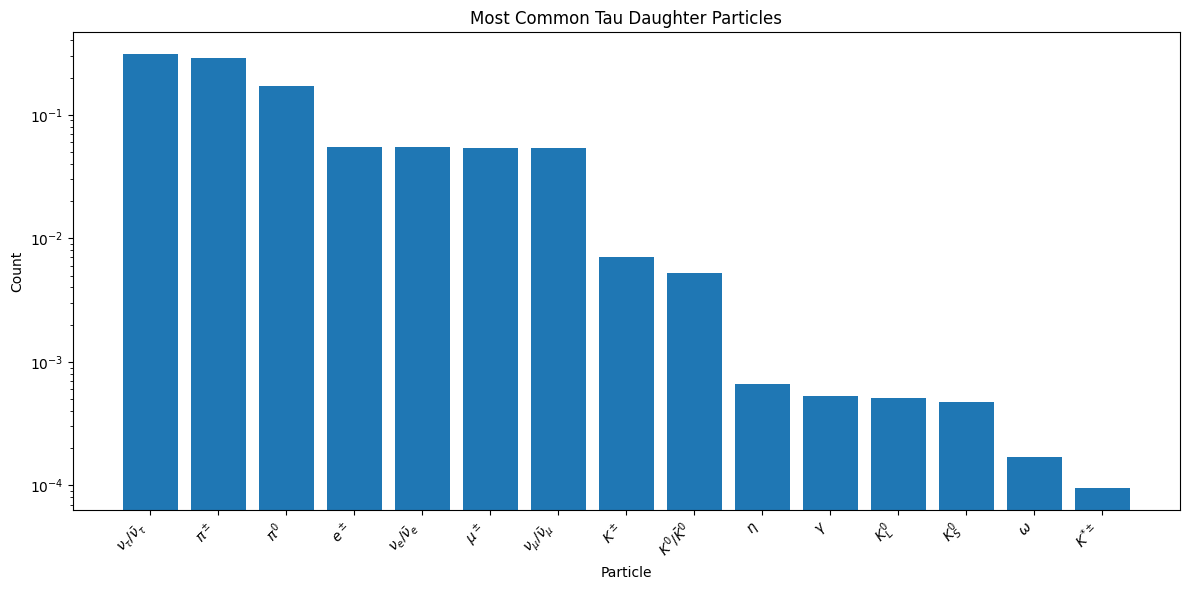

In [22]:
import matplotlib.pyplot as plt

# cz is your {latex_label: count} dictionary
labels = list(cz.keys())
values = list(cz.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, np.array(values)/sum_)
plt.ylabel("Count")
plt.xlabel("Particle")
plt.yscale("log")
plt.title("Most Common Tau Daughter Particles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
from collections import Counter
import numpy as np

decay_modes = Counter()

for path in tqdm(files):
    with uproot.open(path) as f:
        arrays = f["events"].arrays(branches)

        for event in arrays:
            d_idx = event["_MCParticles_daughters.index"]
            d_begin = event["MCParticles.daughters_begin"]
            d_end = event["MCParticles.daughters_end"]

            tau_mask = (np.abs(event["MCParticles.PDG"]) == 15) & (
                event["MCParticles.generatorStatus"] == 2
            )
            tau_indices = np.where(tau_mask)[0]

            for tau_idx in tau_indices:
                daughter_indices = d_idx[d_begin[tau_idx]: d_end[tau_idx]]

                # build unordered, signless decay signature
                decay = tuple(
                    sorted(
                        abs(int(event["MCParticles.PDG"][d]))
                        for d in daughter_indices
                    )
                )

                decay_modes[decay] += 1

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [25:05<00:00,  1.51s/it]


In [29]:
print(decay_modes.most_common(30))

[((16, 111, 211), 50686), ((11, 12, 16), 35433), ((13, 14, 16), 34578), ((16, 211), 21466), ((16, 211, 211, 211), 18738), ((16, 111, 111, 211), 18469), ((16, 111, 211, 211, 211), 9206), ((16, 111, 111, 111, 211), 2089), ((16, 211, 311), 1707), ((16, 321), 1370), ((16, 111, 111, 211, 211, 211), 999), ((16, 111, 321), 815), ((16, 111, 211, 311), 805), ((16, 211, 211, 321), 685), ((16, 22, 111, 211), 343), ((16, 111, 311, 321), 314), ((16, 311, 321), 308), ((16, 211, 321, 321), 306), ((16, 111, 211, 221), 276), ((16, 130, 211, 310), 209), ((16, 211, 211, 211, 211, 211), 177), ((16, 111, 111, 111, 111, 211), 168), ((16, 111, 111, 321), 130), ((16, 111, 111, 111, 321), 118), ((16, 111, 211, 311, 311), 70), ((16, 223, 321), 68), ((16, 221, 323), 61), ((16, 130, 130, 211), 59), ((16, 111, 111, 211, 311), 57), ((16, 111, 211, 211, 321), 54)]


In [30]:
def pdg_to_label(pdg):
    return pdg_to_latex.get(pdg, str(pdg))

# keys are tuples like (111, 211, 16)

labeled_decay_modes = Counter()

for decay, count in decay_modes.items():
    labeled_decay = tuple(pdg_to_label(p) for p in decay)
    labeled_decay_modes[labeled_decay] += count

for mode, c in labeled_decay_modes.most_common(20):
    print(mode, c)

('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$\\pi^\\pm$') 50686
('$e^\\pm$', '$\\nu_e / \\bar{\\nu}_e$', '$\\nu_\\tau / \\bar{\\nu}_\\tau$') 35433
('$\\mu^\\pm$', '$\\nu_\\mu / \\bar{\\nu}_\\mu$', '$\\nu_\\tau / \\bar{\\nu}_\\tau$') 34578
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^\\pm$') 21466
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^\\pm$', '$\\pi^\\pm$', '$\\pi^\\pm$') 18738
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$\\pi^0$', '$\\pi^\\pm$') 18469
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$\\pi^\\pm$', '$\\pi^\\pm$', '$\\pi^\\pm$') 9206
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$\\pi^0$', '$\\pi^0$', '$\\pi^\\pm$') 2089
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^\\pm$', '$K^0 / \\bar{K}^0$') 1707
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$K^\\pm$') 1370
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$\\pi^0$', '$\\pi^\\pm$', '$\\pi^\\pm$', '$\\pi^\\pm$') 999
('$\\nu_\\tau / \\bar{\\nu}_\\tau$', '$\\pi^0$', '$K^\\pm$') 815
('$\\nu_\\tau / \\bar{\\nu}

In [39]:
dmc = {}
for mode, c in labeled_decay_modes.most_common(100):
    dmc[",".join(mode)] = c
dmc

{'$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^\\pm$': 50686,
 '$e^\\pm$,$\\nu_e / \\bar{\\nu}_e$,$\\nu_\\tau / \\bar{\\nu}_\\tau$': 35433,
 '$\\mu^\\pm$,$\\nu_\\mu / \\bar{\\nu}_\\mu$,$\\nu_\\tau / \\bar{\\nu}_\\tau$': 34578,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^\\pm$': 21466,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^\\pm$,$\\pi^\\pm$,$\\pi^\\pm$': 18738,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^0$,$\\pi^\\pm$': 18469,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^\\pm$,$\\pi^\\pm$,$\\pi^\\pm$': 9206,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^0$,$\\pi^0$,$\\pi^\\pm$': 2089,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^\\pm$,$K^0 / \\bar{K}^0$': 1707,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$K^\\pm$': 1370,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^0$,$\\pi^\\pm$,$\\pi^\\pm$,$\\pi^\\pm$': 999,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$K^\\pm$': 815,
 '$\\nu_\\tau / \\bar{\\nu}_\\tau$,$\\pi^0$,$\\pi^\\pm$,$K^0 / \\bar{K}^0$': 805,
 '$\\nu_\\tau / \\bar{\\nu

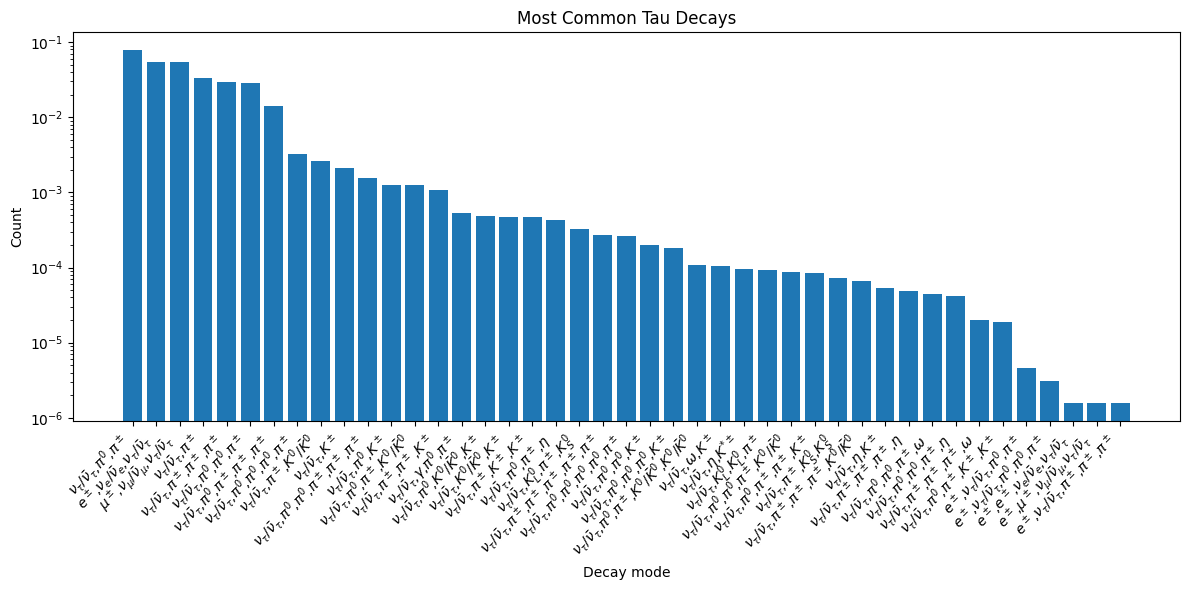

In [40]:
import matplotlib.pyplot as plt

# cz is your {latex_label: count} dictionary
labels = list(dmc.keys())
values = list(dmc.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, np.array(values)/sum_)
plt.ylabel("Count")
plt.xlabel("Decay mode")
plt.yscale("log")
plt.title("Most Common Tau Decays")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()